# Resampling Visualization

Visualizes how the resampling function distributes energy
from irregularly-spaced load profile entries into a uniform time grid.

Loads pre-generated case data from the `cases/` folder.
Select a specific case using the `CASE_NAME` parameter below.

In [20]:
import os

%matplotlib inline
%load_ext autoreload
%autoreload 2

from ethos_penalps.testing.load_profile.resampling_helpers import (
    list_available_cases,
    load_resampling_test_case,
    plot_compare_energy,
    plot_duration_distribution,
    plot_input_vs_resampled,
    plot_input_vs_resampled_energy,
)

CASES_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "cases")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Select a Case

In [21]:
# List available cases
available_cases = list_available_cases(CASES_DIR)
print("Available cases:")
for case in available_cases:
    print(f"  - {case}")

# Select a case by name (set to None to use the first available case)
CASE_NAME = "zero_energy_entries"
if CASE_NAME is None:
    CASE_NAME = available_cases[0]
print(f"\nSelected case: {CASE_NAME}")

Available cases:
  - entries_aligned_to_grid
  - large_spike_rest_tiny
  - many_entries_single_bin
  - mixed_duration_varying_energy
  - one_entry_spanning_many_bins
  - random_seed_1042_1800s_7.5min
  - random_seed_7_900s_1.25min
  - short_spike_not_grid_aligned
  - single_long_entry
  - sub_minute_entries_5min_resample
  - uniform_energy_equal_duration
  - zero_energy_entries

Selected case: zero_energy_entries


## Load Case Data

In [22]:
case_dir = os.path.join(CASES_DIR, CASE_NAME)
meta, resampled_result, parameters = load_resampling_test_case(case_dir)

RESAMPLE_FREQUENCY = parameters["resample_frequency"]
START = meta.first_start_time

print(f"Input: {len(meta.list_of_load_profiles)} entries, Output: {len(resampled_result.list_of_load_profiles)} bins")
print(f"Time range: {parameters['start']} to {parameters['end']}")
print(f"Resample frequency: {RESAMPLE_FREQUENCY}")

Input: 6 entries, Output: 6 bins
Time range: 2021-01-01T00:00:00 to 2021-01-01T00:06:00
Resample frequency: 1min


## 1. Input vs. Resampled Power Profile

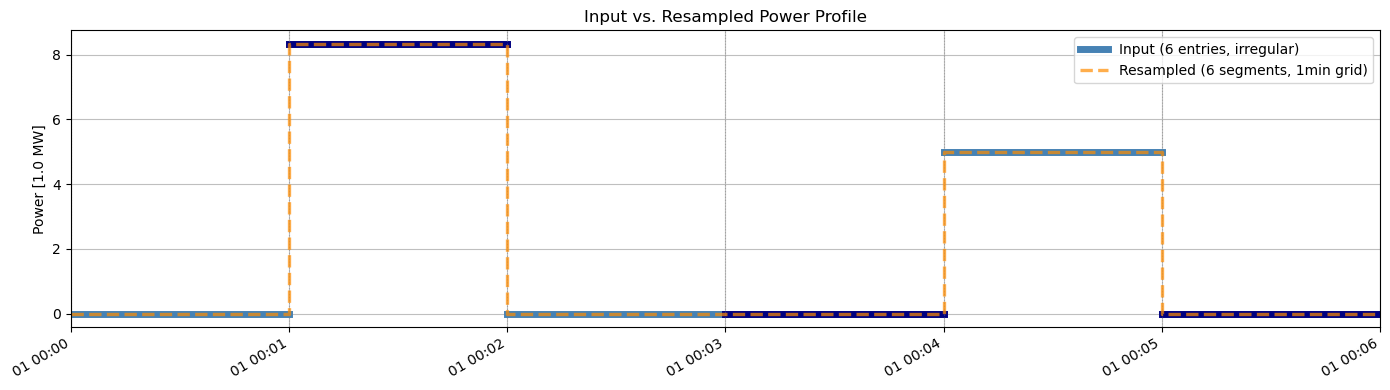

In [23]:
plot_input_vs_resampled(meta, resampled_result)

## 2. Energy Comparison: Input Entries vs. Resampled Bins

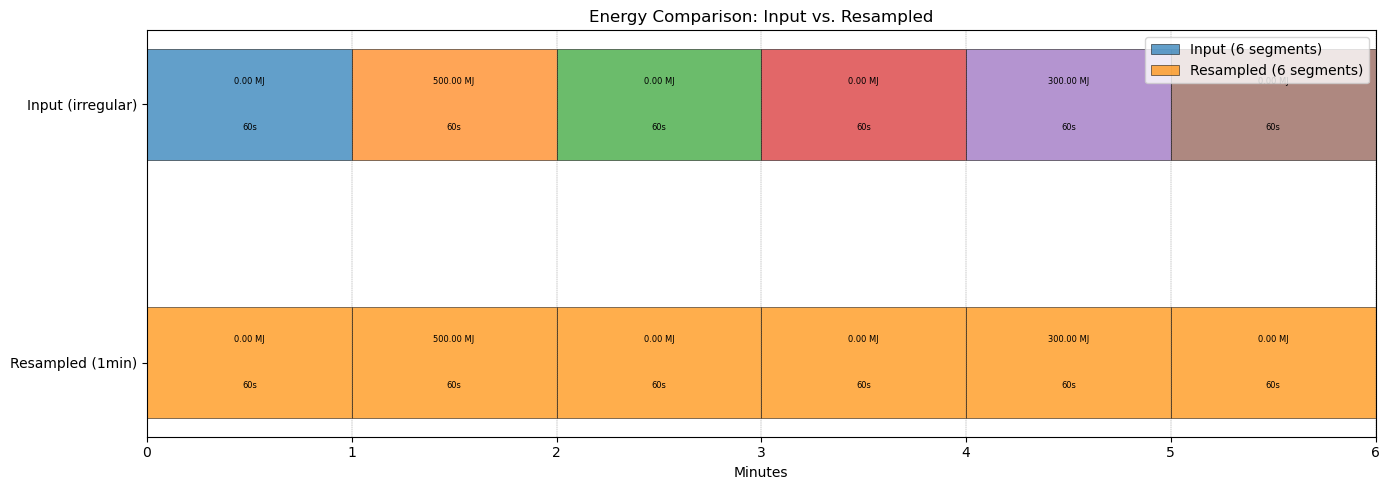

In [24]:
plot_compare_energy(meta, resampled_result)

## 3. Cumulative Energy: Input vs. Resampled

For aligned cases both curves should converge to the same total.

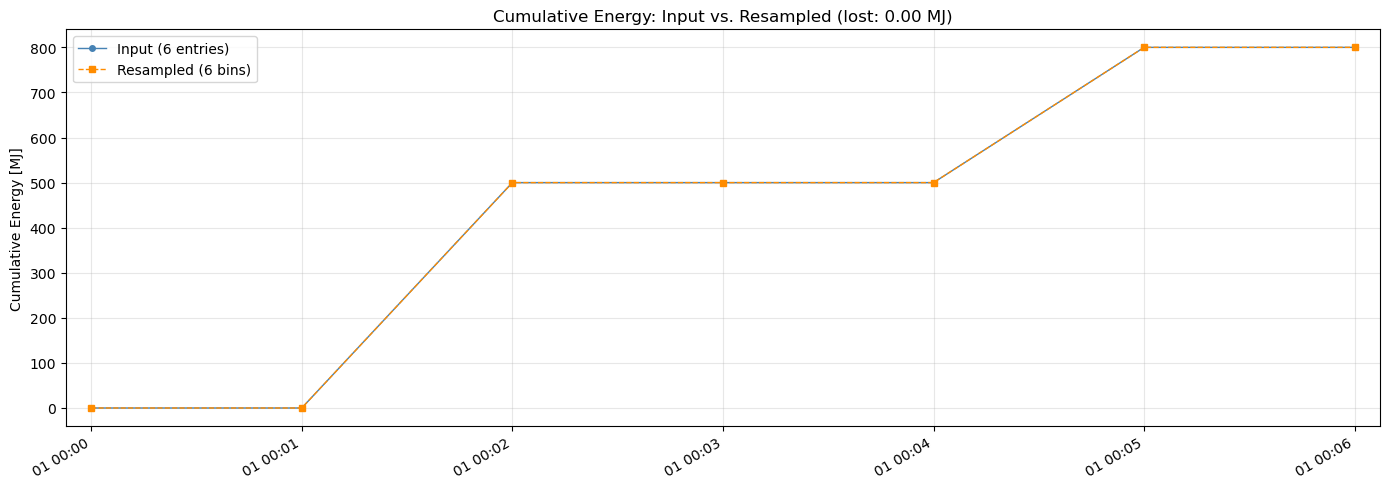

In [25]:
plot_input_vs_resampled_energy(meta, resampled_result)

## 4. Distribution of Input Entry Durations

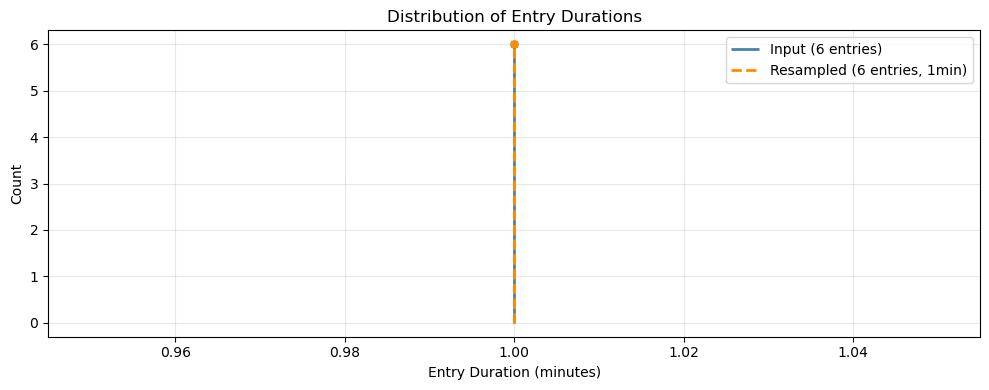

In [26]:
plot_duration_distribution(meta, resampled_result)